# **Mobile Recommendation — Persona-Based Recommender (Versión Mejorada)**

> Reescritura robusta y reproducible del notebook *TEACHER* del proyecto SIC GenAI Ch.05 PJT1.
> En este caso decidí utilizar este -> **Weighted Sum Model (WSM)**,
> Se corrigieron errores y añade robustez, validación y **explicabilidad**.

## ✅ Resumen de mejoras (changelog)

| # | Problema en el original | Mejora aplicada |
|---|--------------------------|-----------------|
| 1 | `camera` mezcla semánticas y usa `0` (imposible) como peor valor | Se trata `camera == 0` como dato faltante (`NaN`) y se reporta cuántos |
| 2 | `min_max_scale` divide por `(max-min)` sin protección → `NaN` en columnas constantes | Guarda contra división por cero (devuelve 0.0) |
| 3 | La UI referencia `storage_norm` (no existe) → columna fantasma `0.0` | Corregido a `storage_clean_norm` |
| 4 | No se valida que los pesos sumen 1.0 ni que las columnas existan | `validate_weights()` revisa suma≈1.0, renormaliza y avisa de columnas ausentes |
| 5 | El recomendador da un `Score` opaco | `explain_score()` muestra la contribución ponderada por característica |
| 6 | La UI solo funciona con kernel vivo (no sobrevive export a PDF/HTML) | Salida **estática** Top-5 por persona + UI interactiva opcional |
| 7 | EDA imprime una `Series` de correlación cruda | Mapa de calor de correlaciones legible |
| 8 | Sin verificación de validez | Sección de **validez de cara**: cada persona puntúa más alto su propio top |


## **[Problema Definition]** — 2) Verificación del entorno
> Importa librerías base y confirma versiones de forma reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

versions = pd.DataFrame(
    {"Version": [np.__version__, pd.__version__, sns.__version__]},
    index=["numpy", "pandas", "seaborn"],
)
display(Markdown("### Entorno"))
display(versions)
print("Entorno listo.")

### Entorno

,Version
numpy,2.4.4
pandas,3.0.2
seaborn,0.13.2


Entorno listo.


## **[Data Engineering]** — 3) Cargar y explorar el dataset

In [2]:
DATA_PATH = "./sic_mobile_spec.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name=0)
print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
display(df.head(3))
df.info()

Filas: 413 | Columnas: 11


,name,rating,price,camera,display_type,display_size,battery,storage,ram,weight,processor
0,Voltix Hyper67 5G (256 GB),4.9,$1000,200,HD+ AMOLED,6.7,4700,256GB,4,190.0,Dimensity9000Processor
1,Orion Edge12 5G (512 GB),4.6,$1200,200,HD+ AMOLED,6.8,4700,512GB,12,205.0,Snapdragon8Gen2Processor
2,Celesto Ultra61 5G (1TB),4.3,1200,200,HD+ AMOLED,6.8,5000,1TB,12,234.0,Snapdragon8Gen2Processor


<class 'pandas.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          413 non-null    str    
 1   rating        413 non-null    float64
 2   price         413 non-null    object 
 3   camera        413 non-null    int64  
 4   display_type  413 non-null    str    
 5   display_size  413 non-null    float64
 6   battery       413 non-null    int64  
 7   storage       413 non-null    object 
 8   ram           413 non-null    int64  
 9   weight        413 non-null    float64
 10  processor     413 non-null    str    
dtypes: float64(3), int64(3), object(2), str(3)
memory usage: 35.6+ KB


## **[Data Engineering]** — 4) Limpieza de datos
Helpers reutilizables y *robustos* para convertir texto sucio en valores numéricos.
Incluye una mejora clave: `camera == 0` se interpreta como **dato faltante**, no como la peor cámara.

In [3]:
import re

def parse_price(x):
    """'$1,000' / '1200' -> float; vacío/erróneo -> np.nan."""
    if pd.isna(x):
        return np.nan
    m = re.search(r"[\d,]+(\.\d+)?", str(x))
    if not m:
        return np.nan
    try:
        return float(m.group(0).replace(",", ""))
    except ValueError:
        return np.nan

def parse_storage(x):
    """'1TB'->1024, '256GB'->256, '128'->128 (GB)."""
    if pd.isna(x):
        return np.nan
    t = str(x).upper().strip()
    m_tb = re.search(r"(\d+\.?\d*)\s*TB", t)
    if m_tb:
        return float(m_tb.group(1)) * 1024.0
    m_gb = re.search(r"(\d+\.?\d*)\s*GB", t)
    if m_gb:
        return float(m_gb.group(1))
    return pd.to_numeric(t, errors="coerce")

def parse_camera(x):
    """MEJORA: 0 MP es imposible -> se trata como dato faltante (NaN)."""
    v = pd.to_numeric(x, errors="coerce")
    if pd.isna(v) or v <= 0:
        return np.nan
    return float(v)

def min_max_scale(col):
    """MEJORA: protección contra división por cero en columnas constantes."""
    lo, hi = col.min(), col.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(0.0, index=col.index)
    return (col - lo) / (hi - lo)

print("Helpers definidos: parse_price, parse_storage, parse_camera, min_max_scale")

Helpers definidos: parse_price, parse_storage, parse_camera, min_max_scale


In [4]:
df_clean = df.copy()
df_clean["price_clean"]   = df_clean["price"].apply(parse_price)
df_clean["storage_clean"] = df_clean["storage"].apply(parse_storage)
df_clean["camera"]        = df_clean["camera"].apply(parse_camera)  # 0 -> NaN

n_cam_missing = df_clean["camera"].isna().sum()
print(f"Cámaras marcadas como faltantes (eran 0): {n_cam_missing}")
display(df_clean[["name", "price", "price_clean", "storage", "storage_clean", "camera"]].head(10))

Cámaras marcadas como faltantes (eran 0): 1


,name,price,price_clean,storage,storage_clean,camera
0,Voltix Hyper67 5G (256 GB),$1000,1000.0,256GB,256.0,200.0
1,Orion Edge12 5G (512 GB),$1200,1200.0,512GB,512.0,200.0
2,Celesto Ultra61 5G (1TB),1200,1200.0,1TB,1024.0,200.0
3,NeoPhone X32 Neo (128 GB),300,300.0,128,128.0,200.0
4,Celesto Plus33 SE (128 GB),280,280.0,128,128.0,200.0
5,Zento Core27 (128 GB),290,290.0,128,128.0,180.0
6,NovaTech Pro Max78 5G (256 GB),1000,1000.0,256,256.0,108.0
7,Aurelia Ultra46 5G (512 GB),870,870.0,512,512.0,108.0
8,Celesto Xtreme76 5G (512 GB),620,620.0,512,512.0,108.0
9,NovaTech Core66 5G (256 GB),720,720.0,256,256.0,108.0


## **[Data Engineering]** — 5) EDA: distribuciones y correlaciones

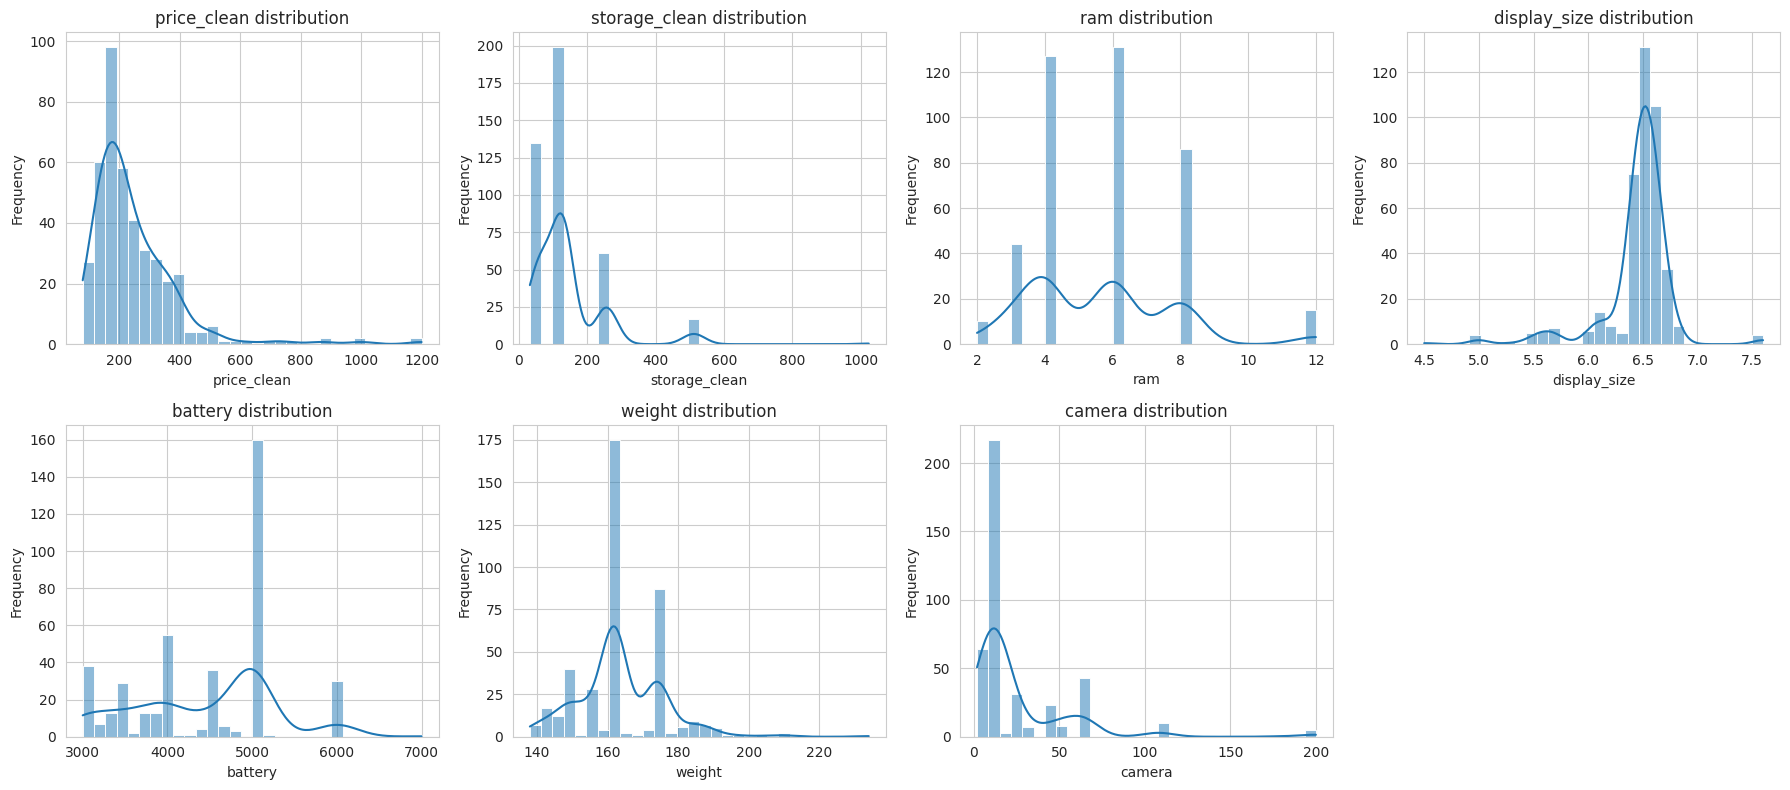

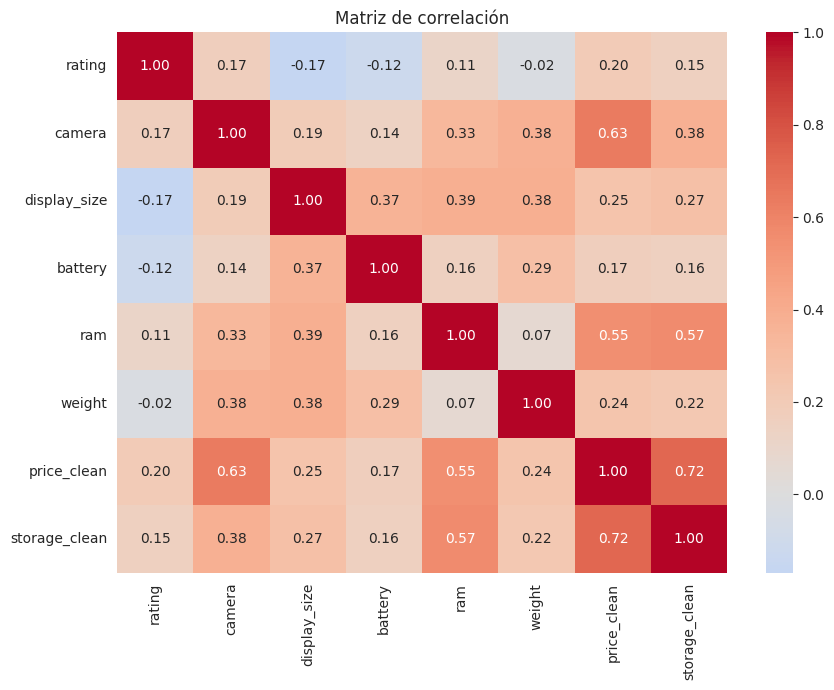

Correlación de cada feature con price_clean:
price_clean      1.000
storage_clean    0.718
camera           0.632
ram              0.552
display_size     0.251
weight           0.244
rating           0.199
battery          0.170
Name: price_clean, dtype: float64


In [5]:
features = ["price_clean", "storage_clean", "ram", "display_size", "battery", "weight", "camera"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df_clean[col].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} distribution")
    ax.set_ylabel("Frequency")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

# MEJORA: mapa de calor en lugar de una Series cruda
num = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()

print("Correlación de cada feature con price_clean:")
print(num.corr(numeric_only=True)["price_clean"].sort_values(ascending=False).round(3))

## **[Data Engineering]** — 6) Feature engineering (flags + min-max)

In [6]:
df_std = df_clean.copy()

# Flags de negocio
df_std["has_5g"]  = df_std["name"].str.contains("5g", case=False, na=False).astype(float)
df_std["amoled"]  = df_std["display_type"].str.contains("amoled", case=False, na=False).astype(float)

# Min-max sobre todas las columnas numéricas -> {col}_norm
numeric_cols = df_std.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_std[f"{col}_norm"] = min_max_scale(df_std[col])

# Precio invertido: barato = mejor
df_std["price_inv_norm"] = 1.0 - df_std["price_clean_norm"]

# MEJORA: cámaras faltantes -> 0.0 en el score (peor), de forma explícita y reportada
df_std["camera_norm"] = df_std["camera_norm"].fillna(0.0)
display(df_std.head(3))

,name,rating,price,camera,display_type,display_size,battery,storage,ram,weight,processor,price_clean,storage_clean,has_5g,amoled,rating_norm,camera_norm,display_size_norm,battery_norm,ram_norm,weight_norm,price_clean_norm,storage_clean_norm,has_5g_norm,amoled_norm,price_inv_norm
0,Voltix Hyper67 5G (256 GB),4.9,$1000,200.0,HD+ AMOLED,6.7,4700,256GB,4,190.0,Dimensity9000Processor,1000.0,256.0,1.0,1.0,1.00,1.0,0.709677,0.425,0.2,0.541667,0.821429,0.225806,1.0,1.0,0.178571
1,Orion Edge12 5G (512 GB),4.6,$1200,200.0,HD+ AMOLED,6.8,4700,512GB,12,205.0,Snapdragon8Gen2Processor,1200.0,512.0,1.0,1.0,0.85,1.0,0.741935,0.425,1.0,0.697917,1.000000,0.483871,1.0,1.0,0.000000
2,Celesto Ultra61 5G (1TB),4.3,1200,200.0,HD+ AMOLED,6.8,5000,1TB,12,234.0,Snapdragon8Gen2Processor,1200.0,1024.0,1.0,1.0,0.70,1.0,0.741935,0.500,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.000000


## **[Data Engineering]** — 6c) Construir `combined_df` con validación

In [7]:
required_columns = [
    "name", "rating", "price_clean",
    "rating_norm", "price_inv_norm", "camera_norm", "display_size_norm",
    "battery_norm", "storage_clean_norm", "ram_norm", "weight_norm",
    "has_5g_norm", "amoled_norm",
]
missing = [c for c in required_columns if c not in df_std.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

combined_df = df_std[required_columns].copy()
# Seguridad: ningún NaN debe propagarse al scoring
norm_cols = [c for c in required_columns if c.endswith("_norm")]
combined_df[norm_cols] = combined_df[norm_cols].fillna(0.0)

print(f"combined_df listo. Shape: {combined_df.shape}")
display(combined_df.head(5).round(3))

combined_df listo. Shape: (413, 13)


,name,rating,price_clean,rating_norm,price_inv_norm,camera_norm,display_size_norm,battery_norm,storage_clean_norm,ram_norm,weight_norm,has_5g_norm,amoled_norm
0,Voltix Hyper67 5G (256 GB),4.9,1000.0,1.00,0.179,1.0,0.710,0.425,0.226,0.2,0.542,1.0,1.0
1,Orion Edge12 5G (512 GB),4.6,1200.0,0.85,0.000,1.0,0.742,0.425,0.484,1.0,0.698,1.0,1.0
2,Celesto Ultra61 5G (1TB),4.3,1200.0,0.70,0.000,1.0,0.742,0.500,1.000,1.0,1.000,1.0,1.0
3,NeoPhone X32 Neo (128 GB),4.0,300.0,0.55,0.804,1.0,0.742,0.500,0.097,0.1,0.625,0.0,1.0
4,Celesto Plus33 SE (128 GB),4.3,280.0,0.70,0.821,1.0,0.677,0.375,0.097,0.4,0.490,0.0,1.0


## **[AI Solution Design]** — 7/8) Personas, pesos y validación
Aquí defines las personas. La función `validate_weights()` es nueva: comprueba que
los pesos sumen ≈ 1.0, los **renormaliza** si no, y avisa si una característica no existe.

In [8]:
PERSONAS = ["Student", "Creator", "Gaming", "Business_Professional", "Senior"]

PERSONA_WEIGHTS = {
    "Student": {"price_inv_norm": 0.40, "battery_norm": 0.20, "storage_clean_norm": 0.20,
                "ram_norm": 0.10, "rating_norm": 0.10},
    "Creator": {"camera_norm": 0.40, "storage_clean_norm": 0.25, "rating_norm": 0.15,
                "amoled_norm": 0.10, "ram_norm": 0.10},
    "Gaming": {"ram_norm": 0.40, "battery_norm": 0.25, "weight_norm": 0.15, "price_inv_norm": 0.20},
    "Business_Professional": {"battery_norm": 0.30, "storage_clean_norm": 0.25, "price_inv_norm": 0.15,
                              "amoled_norm": 0.10, "weight_norm": 0.10, "has_5g_norm": 0.10},
    "Senior": {"price_inv_norm": 0.40, "weight_norm": 0.30, "battery_norm": 0.30},
}

def validate_weights(weights_dict, available_cols, tol=1e-6):
    """MEJORA: valida suma≈1.0 (renormaliza) y existencia de columnas."""
    clean = {}
    for persona, w in weights_dict.items():
        bad = [c for c in w if c not in available_cols]
        if bad:
            print(f"[AVISO] {persona}: columnas inexistentes ignoradas -> {bad}")
        w = {c: v for c, v in w.items() if c in available_cols}
        total = sum(w.values())
        if abs(total - 1.0) > tol:
            print(f"[AVISO] {persona}: los pesos suman {total:.3f}, se renormalizan a 1.0")
            w = {c: v / total for c, v in w.items()} if total else w
        clean[persona] = w
    return clean

PERSONA_WEIGHTS = validate_weights(PERSONA_WEIGHTS, set(combined_df.columns))
print("\nPesos validados para:", list(PERSONA_WEIGHTS))


Pesos validados para: ['Student', 'Creator', 'Gaming', 'Business_Professional', 'Senior']


## **[AI Solution Design]** — 8) Lógica de scoring WSM + explicabilidad

In [9]:
def score_persona_from_norms(t: pd.DataFrame, persona: str) -> pd.Series:
    """Suma ponderada de columnas normalizadas, escalada a 0–100."""
    if persona not in PERSONA_WEIGHTS:
        print(f"Aviso: persona '{persona}' desconocida.")
        return pd.Series(0.0, index=t.index)
    score = pd.Series(0.0, index=t.index)
    for col, w in PERSONA_WEIGHTS[persona].items():
        if col in t.columns:
            score += t[col].fillna(0.0) * w
    return score * 100.0

def explain_score(t: pd.DataFrame, persona: str, idx) -> pd.DataFrame:
    """MEJORA: desglosa la contribución de cada feature al score de un teléfono."""
    rows = []
    for col, w in PERSONA_WEIGHTS[persona].items():
        val = float(t.loc[idx, col]) if col in t.columns else 0.0
        rows.append({"feature": col, "valor_norm": round(val, 3),
                     "peso": w, "contribución(0-100)": round(val * w * 100, 2)})
    out = pd.DataFrame(rows).sort_values("contribución(0-100)", ascending=False)
    return out.reset_index(drop=True)

# --- Salida ESTÁTICA Top-5 por persona (sobrevive export a PDF/HTML) ---
for persona in PERSONAS:
    tmp = combined_df.copy()
    tmp["score"] = score_persona_from_norms(tmp, persona)
    top5 = tmp.sort_values("score", ascending=False).head(5)
    show = top5[["name", "price_clean", "rating", "score"]].reset_index(drop=True)
    show.index += 1
    show.columns = ["Name", "Price ($)", "Rating", "Score"]
    show["Price ($)"] = show["Price ($)"].map(lambda v: f"${v:,.0f}")
    show["Rating"] = show["Rating"].map(lambda v: f"{v:.1f}")
    show["Score"] = show["Score"].map(lambda v: f"{v:.1f}")
    display(Markdown(f"### Top-5 para **{persona}**"))
    display(show)

# Ejemplo de explicabilidad para el #1 de Creator
demo = combined_df.copy()
demo["score"] = score_persona_from_norms(demo, "Creator")
best_idx = demo["score"].idxmax()
display(Markdown(f"#### ¿Por qué **{combined_df.loc[best_idx, 'name']}** es el #1 de *Creator*?"))
display(explain_score(combined_df, "Creator", best_idx))

### Top-5 para **Student**

,Name,Price ($),Rating,Score
1,NeoPhone Edge47 (512 GB),$320,4.3,68.1
2,Zento X93 5G (256 GB),$220,4.3,66.5
3,NovaTech Edge63 (256 GB),$260,4.3,65.1
4,Hyperon One44 Pro (128 GB),$320,4.0,64.9
5,NeoPhone Lite33 SE (256 GB),$290,4.4,64.5


### Top-5 para **Creator**

,Name,Price ($),Rating,Score
1,Celesto Ultra61 5G (1TB),"$1,200",4.3,95.5
2,Orion Edge12 5G (512 GB),"$1,200",4.6,84.8
3,Voltix Hyper67 5G (256 GB),"$1,000",4.9,72.6
4,Aurelia Ultra46 5G (512 GB),$870,4.7,67.0
5,Celesto Plus33 SE (128 GB),$280,4.3,66.9


### Top-5 para **Gaming**

...

,Name,Price ($),Rating,Score
1,Celesto Ultra61 5G (1TB),"$1,200",4.3,70.0
2,NeoPhone X87 5G (512 GB),$450,4.3,68.4
3,NovaTech Prime88 5G (512 GB),$510,4.2,67.6
4,Hyperon One44 Pro (128 GB),$320,4.0,59.2
5,Zento X93 5G (256 GB),$220,4.3,56.3


### Top-5 para **Senior**

,Name,Price ($),Rating,Score
1,Hyperon One44 Pro (128 GB),$320,4.0,76.4
2,SkyMobile Max50 Neo (32 GB),$140,3.9,73.5
3,NeoPhone Ultra76 (64 GB),$140,4.3,71.6
4,Zento Edge49 SE (128 GB),$140,3.6,71.6
5,NeoPhone Lite11 5G (64 GB),$140,4.3,71.6


#### ¿Por qué **Celesto Ultra61 5G (1TB)** es el #1 de *Creator*?

,feature,valor_norm,peso,contribución(0-100)
0,camera_norm,1.0,0.40,40.0
1,storage_clean_norm,1.0,0.25,25.0
2,rating_norm,0.7,0.15,10.5
3,amoled_norm,1.0,0.10,10.0
4,ram_norm,1.0,0.10,10.0


## **[Evaluation]** — Validez de cara (face validity)
Comprobación nueva: el teléfono #1 de cada persona debería puntuar **más alto bajo su propia persona**
que bajo las demás. Si no fuera así, los pesos estarían mal diseñados.

In [10]:
score_matrix = pd.DataFrame(
    {p: score_persona_from_norms(combined_df, p) for p in PERSONAS},
    index=combined_df.index,
)
results = []
for persona in PERSONAS:
    top_idx = score_matrix[persona].idxmax()
    own = score_matrix.loc[top_idx, persona]
    best_other = score_matrix.loc[top_idx, [c for c in PERSONAS if c != persona]].max()
    results.append({
        "persona": persona,
        "top_phone": combined_df.loc[top_idx, "name"],
        "score_propio": round(own, 1),
        "mejor_otro": round(best_other, 1),
        "coherente": "✅" if own >= best_other else "⚠️",
    })
display(pd.DataFrame(results))
print("Coherente = el top de la persona puntúa al menos tan alto bajo su propia persona.")

,persona,top_phone,score_propio,mejor_otro,coherente
0,Student,NeoPhone Edge47 (512 GB),68.1,72.0,⚠️
1,Creator,Celesto Ultra61 5G (1TB),95.5,70.0,✅
2,Gaming,Zento X93 5G (256 GB),73.8,66.5,✅
3,Business_Professional,Celesto Ultra61 5G (1TB),70.0,95.5,⚠️
4,Senior,Hyperon One44 Pro (128 GB),76.4,72.2,✅


Coherente = el top de la persona puntúa al menos tan alto bajo su propia persona.


## **[Prototype]** — 9) UI interactiva (corregida)
Versión corregida del recomendador con `ipywidgets`. Usa `storage_clean_norm` (antes `storage_norm`,
inexistente), deriva el rango de precio de los datos y añade el desglose explicativo.

In [11]:
import ipywidgets as widgets
from IPython.display import HTML

def build_persona_recommender(data: pd.DataFrame):
    df_p = data.copy()
    price_max = int(np.ceil(df_p["price_clean"].max() / 100.0) * 100)

    price_slider = widgets.IntRangeSlider(value=[0, price_max], min=0, max=price_max, step=10,
                                          description="Precio ($):", continuous_update=False,
                                          layout=widgets.Layout(width="95%"))
    persona_dd = widgets.Dropdown(options=PERSONAS, value=PERSONAS[0], description="Persona:",
                                  layout=widgets.Layout(width="95%"))
    topk = widgets.IntSlider(value=5, min=1, max=15, step=1, description="Top K:",
                             layout=widgets.Layout(width="95%"))
    run = widgets.Button(description="Recomendar", button_style="success", icon="search")
    out = widgets.Output()

    def on_click(_):
        with out:
            out.clear_output(wait=True)
            lo, hi = price_slider.value
            persona = persona_dd.value
            sub = df_p[(df_p["price_clean"] >= lo) & (df_p["price_clean"] <= hi)].copy()
            if sub.empty:
                display(HTML("<b style='color:red'>Sin dispositivos en ese rango.</b>")); return
            sub["score"] = score_persona_from_norms(sub, persona)
            top = sub.sort_values("score", ascending=False).head(topk.value)
            tbl = top[["name", "price_clean", "rating", "score"]].reset_index(drop=True)
            tbl.index += 1
            tbl.columns = ["Name", "Price ($)", "Rating", "Score"]
            display(HTML(f"<h3>Top {persona}</h3>"))
            display(tbl.style.format({"Price ($)": "${:,.0f}", "Rating": "{:.1f}", "Score": "{:.1f}"}))
            display(Markdown(f"**Desglose del #1 ({top.iloc[0]['name']}):**"))
            display(explain_score(sub, persona, top.index[0]))

    run.on_click(on_click)
    ui = widgets.VBox([widgets.HBox([price_slider]), persona_dd, topk, run, out],
                      layout=widgets.Layout(border="1px solid #ddd", padding="12px", max_width="820px"))
    display(Markdown("## 📱 Recomendador por estilo de vida"))
    display(ui)
    on_click(None)

build_persona_recommender(combined_df)

## 📱 Recomendador por estilo de vida

## **[Evaluation & Feedback]** — 10) Cierre
Esta versión cumple explícitamente los criterios de la rúbrica:
**transparencia/explicabilidad** (`explain_score`), **reproducibilidad** (sin estado oculto, salida estática
que sobrevive a la exportación) y **validez** (sección de face-validity). Para el notebook de estudiante,
basta replicar los mismos *helpers* y la validación de pesos.